In [58]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
import pandas as pd
from unsflow.utils.thesis_plots import *

In [59]:
su2File = "su2_lowerwall.csv"
ctbfmFiles = [
    '../air_ideal_roe1/Volume_CSV/results.csv',
    '../air_ideal_roe2/Volume_CSV/results.csv',
    '../air_ideal_jst/Volume_CSV/results.csv',
    '../air_real_roe1/Volume_CSV/results.csv',
    '../air_real_roe2/Volume_CSV/results.csv',
    '../air_real_jst/Volume_CSV/results.csv',
    ]

ctbfms_labs = [f.split('/')[1].split('air_')[1] for f in ctbfmFiles]

In [60]:
su2 = pd.read_csv(su2File)

In [61]:
ctbfms = []
for ctbfmFile in ctbfmFiles:
    with open(ctbfmFile, 'r') as f:
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])

    df = pd.read_csv(ctbfmFile, skiprows=3)
    ctbfm = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    ctbfms.append(ctbfm)

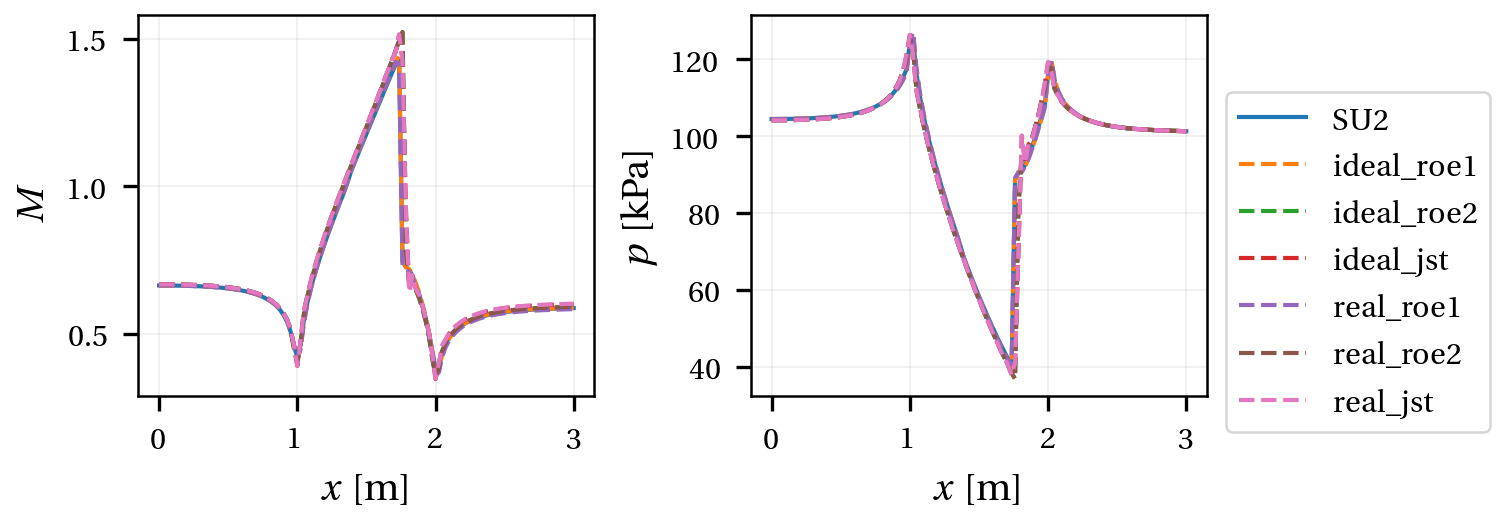

In [64]:
# Create figure and axes
set_thesis_style()
fig, (ax1, ax2) = create_figure(fraction=1.0, aspect_ratio=1.45, subplots=(1, 2))

# Primary y-axis: Mach number (C0)
ax1.plot(su2['Points_0'], su2['Mach'], '-', mfc='none', color='C0', label='SU2')
for ii,ctbfm in enumerate(ctbfms):
    ax1.plot(ctbfm['x'][:,0,0], ctbfm['Mach'][:,0,0], '--', mfc='none', color='C%i' % (ii+1), label=ctbfms_labs[ii])
ax1.set_xlabel(r'$x$ [m]')
ax1.set_ylabel(r'$M$')
ax1.grid(alpha=0.2)

# Secondary y-axis: Pressure (C1)
# ax2 = ax1.twinx()
ax2.plot(su2['Points_0'], su2['Pressure']/1000, '-', mfc='none', color='C0')
for ii,ctbfm in enumerate(ctbfms):
    ax2.plot(ctbfm['x'][:,0,0], ctbfm['Pressure'][:,0,0]/1000, '--', mfc='none', color='C%i' % (ii+1))
ax2.set_ylabel(r'$p$ [kPa]')
ax2.set_xlabel(r'$x$ [m]')
ax2.grid(alpha=0.2)


# Build custom legend: only two entries (SU2 and Current)

fig.legend(loc='outside right')
# Save figure
plt.savefig("comparison.pdf")
# plt.show()